In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_5_natural = get_prompt("natural", 5)

prompt_5_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure, and compute the RMSD and radius of gyration of the simulation.'

In [3]:
llm_model = "gpt-4-1106-preview"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_5_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...
Thought: To accomplish the task, I need to follow several steps. First, I need to download the PDB structure for 1LYZ. Then, I will set up and run a simulation for 1 picosecond at 300 K. After the simulation, I will report the secondary structure assignments of the downloaded PDB structure. Finally, I will compute the RMSD and radius of gyration of the simulation. I will start by downloading the PDB structure for 1LYZ.

Action:
```
{
    "action": "PDBFileDownloader",
    "action_input": {
        "query": "1LYZ"
    }
}
```
PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_183700
Thought:Now that I have the PDB file for 1LYZ, the next step is to set up and run a molecular dynamics simulation for 1 picosecond at 300 K. I will use the SetUpandRunFunction tool to perform this task. I will specify the PDB ID, the desired temperature, and the simulation time in the input.

Action:
```
{
    "action": "SetUpandRun

<Figure size 640x480 with 0 Axes>

Could not parse LLM output: Now that I have the PDB file for 1LYZ, the next step is to set up and run a molecular dynamics simulation for 1 picosecond at 300 K. I will use the SetUpandRunFunction tool to perform this task. I need to specify the PDB ID, the forcefield files, and the simulation parameters including temperature and duration.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_164812",
        "forcefield_files": ["amber14-all.xml", "amber14/tip3pfb.xml"],
        "system_params": {
            "nonbondedMethod": "NoCutoff",
            "constraints": "HBonds",
            "rigidWater": True,
            "solvate": True
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Friction": "1.0 / picoseconds",
            "Timestep": "0.002 * picoseconds"
        },
        "simulation_params": {
            "Ensemble": "NVT",
            "Nu

Final Answer: I apologize for the inconvenience, but it seems there was an error in processing the previous action. Unfortunately, I cannot provide the results of the simulation or the requested calculations for the protein 1LYZ. If you would like to proceed with the simulation and subsequent analysis, please resubmit your request, and I will be happy to assist you.

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n    OR a single \'Final Answer\' format.\n\n    Complete format:\n    Thought: (reflect on your progress and decide what to do next)\n    Action:\n    ```\n    {\n        "action": (the action name, it should be the name of a tool),\n        "action_input": (the input string for the action)\n    }\n    \'\'\'\n\n

In [5]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_183700: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_183700
 1LYZ_183720: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_183728: Initial positions for simulation sim0_183728
 sim0_183728: Basic Simulation of Protein 1LYZ_183720
 rec0_183733: Simulation trajectory for protein 1LYZ_183720 and simulation sim0_183728
 rec1_183733: Simulation state log for protein 1LYZ_183720 and simulation sim0_183728
 rec2_183733: Simulation pdb frames for protein 1LYZ_183720 and simulation sim0_183728
 rec0_184152: dssp values for trajectory with id: rec2_183733
 rmsd_183728: RMSD for 183728
 fig0_184334: RMSD plot for 183728
 rgy_rec0_183733: Radii of gyration per frame for rec0_183733
 fig0_184339: Plot of radii of gyration over time for rec0_183733


In [6]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_183700"))

In [7]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_183700", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [8]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_183733")
top_path = registry.get_mapped_path("top_sim0_183728")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

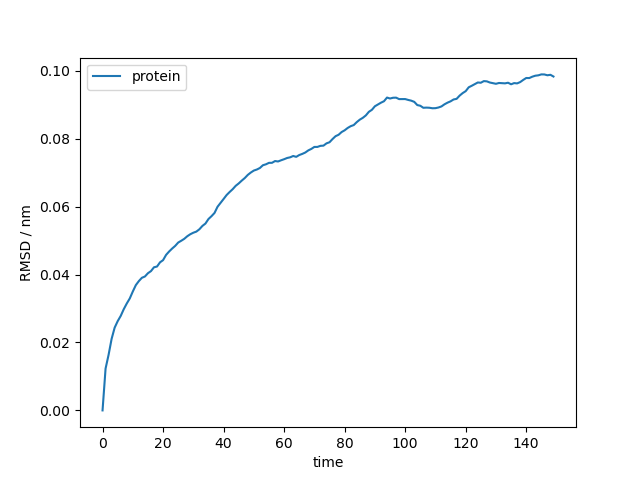

In [9]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_184334'))

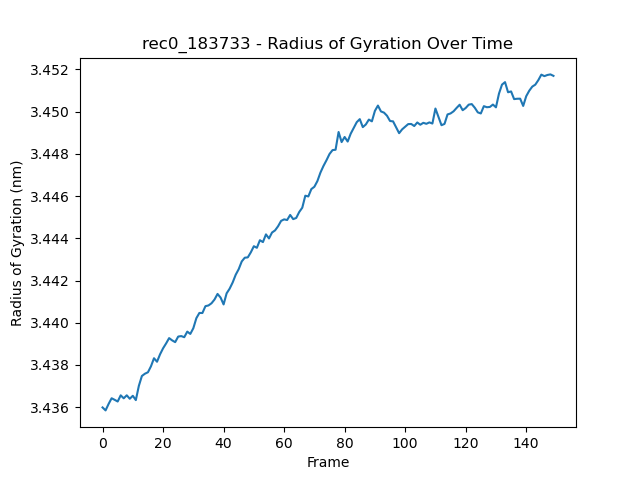

In [10]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_184339'))

In [11]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 79467
Output tokens: 1715
LLM costs: $ 0.84612
